**Step 1: Import the libraries**



In [184]:
import pandas as pd
import requests
import sqlite3
import matplotlib.pyplot as plt

**Step 2: Collect data from the GitHub API**

In [185]:
url =  "https://api.github.com/search/repositories?q=machine+learning&sort=stars&order=desc&per_page=100"

In [186]:
response = requests.get(url)

In [187]:
data = response.json()

In [188]:
print("Data collected successfully!")

Data collected successfully!


In [189]:
print("Number of repositories:", len(data["items"]))

Number of repositories: 100


**Step 3: Create the DataFrame**

In [190]:
df = pd.DataFrame(data["items"])

In [191]:
df.head()

,id,node_id,name,full_name,private,owner,html_url,description,fork,url,...,web_commit_signoff_required,has_pull_requests,pull_request_creation_policy,topics,visibility,forks,open_issues,watchers,default_branch,score
0,45717250,MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==,tensorflow,tensorflow/tensorflow,False,"{'login': 'tensorflow', 'id': 15658638, 'node_...",https://github.com/tensorflow/tensorflow,An Open Source Machine Learning Framework for ...,False,https://api.github.com/repos/tensorflow/tensor...,...,False,True,all,"[deep-learning, deep-neural-networks, distribu...",public,76098,2932,197330,master,1.0
1,155220641,MDEwOlJlcG9zaXRvcnkxNTUyMjA2NDE=,transformers,huggingface/transformers,False,"{'login': 'huggingface', 'id': 25720743, 'node...",https://github.com/huggingface/transformers,🤗 Transformers: the model-definition framework...,False,https://api.github.com/repos/huggingface/trans...,...,False,True,all,"[audio, deep-learning, deepseek, gemma, glm, h...",public,34325,2401,164344,main,1.0
2,343965132,MDEwOlJlcG9zaXRvcnkzNDM5NjUxMzI=,ML-For-Beginners,microsoft/ML-For-Beginners,False,"{'login': 'microsoft', 'id': 6154722, 'node_id...",https://github.com/microsoft/ML-For-Beginners,"12 weeks, 26 lessons, 52 quizzes, classic Mach...",False,https://api.github.com/repos/microsoft/ML-For-...,...,False,True,all,"[data-science, education, machine-learning, ma...",public,22038,13,89688,main,1.0
3,145553672,MDEwOlJlcG9zaXRvcnkxNDU1NTM2NzI=,funNLP,fighting41love/funNLP,False,"{'login': 'fighting41love', 'id': 11475294, 'n...",https://github.com/fighting41love/funNLP,中英文敏感词、语言检测、中外手机/电话归属地/运营商查询、名字推断性别、手机号抽取、身份证抽...,False,https://api.github.com/repos/fighting41love/fu...,...,False,True,all,[],public,15272,52,82598,master,1.0
4,21872392,MDEwOlJlcG9zaXRvcnkyMTg3MjM5Mg==,awesome-machine-learning,josephmisiti/awesome-machine-learning,False,"{'login': 'josephmisiti', 'id': 246302, 'node_...",https://github.com/josephmisiti/awesome-machin...,A curated list of awesome Machine Learning fra...,False,https://api.github.com/repos/josephmisiti/awes...,...,False,True,all,[],public,15619,26,74120,master,1.0


In [192]:
print("Rows and columns:", df.shape)

Rows and columns: (100, 82)


In [193]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 82 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            100 non-null    int64  
 1   node_id                       100 non-null    object 
 2   name                          100 non-null    object 
 3   full_name                     100 non-null    object 
 4   private                       100 non-null    bool   
 5   owner                         100 non-null    object 
 6   html_url                      100 non-null    object 
 7   description                   100 non-null    object 
 8   fork                          100 non-null    bool   
 9   url                           100 non-null    object 
 10  forks_url                     100 non-null    object 
 11  keys_url                      100 non-null    object 
 12  collaborators_url             100 non-null    object 
 13  teams_

In [194]:
df. columns

Index(['id', 'node_id', 'name', 'full_name', 'private', 'owner', 'html_url',
       'description', 'fork', 'url', 'forks_url', 'keys_url',
       'collaborators_url', 'teams_url', 'hooks_url', 'issue_events_url',
       'events_url', 'assignees_url', 'branches_url', 'tags_url', 'blobs_url',
       'git_tags_url', 'git_refs_url', 'trees_url', 'statuses_url',
       'languages_url', 'stargazers_url', 'contributors_url',
       'subscribers_url', 'subscription_url', 'commits_url', 'git_commits_url',
       'comments_url', 'issue_comment_url', 'contents_url', 'compare_url',
       'merges_url', 'archive_url', 'downloads_url', 'issues_url', 'pulls_url',
       'milestones_url', 'notifications_url', 'labels_url', 'releases_url',
       'deployments_url', 'created_at', 'updated_at', 'pushed_at', 'git_url',
       'ssh_url', 'clone_url', 'svn_url', 'homepage', 'size',
       'stargazers_count', 'watchers_count', 'language', 'has_issues',
       'has_projects', 'has_downloads', 'has_wiki', 'has

**Step 4: Select the required columns**

In [195]:
df = df[
    [
        "name",
        "owner",
        "language",
        "stargazers_count",
        "forks_count",
        "watchers_count",
        "open_issues_count",
        "created_at",
        "updated_at",
        "license"
    ]
]

In [196]:
df.head()

,name,owner,language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at,updated_at,license
0,tensorflow,"{'login': 'tensorflow', 'id': 15658638, 'node_...",C++,197330,76098,197330,2932,2015-11-07T01:19:20Z,2026-08-22T21:49:21Z,"{'key': 'apache-2.0', 'name': 'Apache License ..."
1,transformers,"{'login': 'huggingface', 'id': 25720743, 'node...",Python,164344,34325,164344,2401,2018-10-29T13:56:00Z,2026-08-22T22:54:19Z,"{'key': 'apache-2.0', 'name': 'Apache License ..."
2,ML-For-Beginners,"{'login': 'microsoft', 'id': 6154722, 'node_id...",Jupyter Notebook,89688,22038,89688,13,2021-03-03T01:34:05Z,2026-08-22T22:43:05Z,"{'key': 'mit', 'name': 'MIT License', 'spdx_id..."
3,funNLP,"{'login': 'fighting41love', 'id': 11475294, 'n...",Python,82598,15272,82598,52,2018-08-21T11:20:39Z,2026-08-22T20:42:24Z,None
4,awesome-machine-learning,"{'login': 'josephmisiti', 'id': 246302, 'node_...",Python,74120,15619,74120,26,2014-07-15T19:11:19Z,2026-08-22T22:52:42Z,"{'key': 'other', 'name': 'Other', 'spdx_id': '..."


**Step 5: Extract the owner username**

In [197]:
def get_owner_name(owner):
    if owner:
        return owner["login"]
    else:
        return "Unknown"

In [198]:
df["owner"] = df["owner"].apply(get_owner_name)

In [199]:
df[["name", "owner"]].head()

,name,owner
0,tensorflow,tensorflow
1,transformers,huggingface
2,ML-For-Beginners,microsoft
3,funNLP,fighting41love
4,awesome-machine-learning,josephmisiti


**Step 6: Extract the license name**

In [200]:
def get_license_name(license):
    if license:
        return license["name"]
    else:
        return "Unknown"

In [201]:
df["license"] = df["license"].apply(get_license_name)

In [202]:
df[["name", "license"]].head()

,name,license
0,tensorflow,Apache License 2.0
1,transformers,Apache License 2.0
2,ML-For-Beginners,MIT License
3,funNLP,Unknown
4,awesome-machine-learning,Other


**Step 7: Check missing values**

In [203]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
name                  0
owner                 0
language             23
stargazers_count      0
forks_count           0
watchers_count        0
open_issues_count     0
created_at            0
updated_at            0
license               0
dtype: int64


In [204]:
df["language"] = df["language"].fillna("Unknown")

In [205]:
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
name                 0
owner                0
language             0
stargazers_count     0
forks_count          0
watchers_count       0
open_issues_count    0
created_at           0
updated_at           0
license              0
dtype: int64


**Step 8: Check for duplicate records**

In [206]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [207]:
df = df.drop_duplicates()

In [208]:
print("Number of duplicate rows after cleaning:", df.duplicated().sum())

Number of duplicate rows after cleaning: 0


**Step 9: Convert the date columns**

In [209]:
df["created_at"] = pd.to_datetime(df["created_at"])

In [210]:
df["updated_at"] = pd.to_datetime(df["updated_at"])

**Step 10: Rename the columns**

In [211]:
df = df.rename(
    columns={
        "stargazers_count": "stars",
        "forks_count": "forks",
        "watchers_count": "watchers",
        "open_issues_count": "open_issues",
        "created_at": "created_date",
        "updated_at": "updated_date"
    }
)

**Step 11: Check the cleaned dataset**

In [212]:
df.head()

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197330,76098,197330,2932,2015-11-07 01:19:20+00:00,2026-08-22 21:49:21+00:00,Apache License 2.0
1,transformers,huggingface,Python,164344,34325,164344,2401,2018-10-29 13:56:00+00:00,2026-08-22 22:54:19+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89688,22038,89688,13,2021-03-03 01:34:05+00:00,2026-08-22 22:43:05+00:00,MIT License
3,funNLP,fighting41love,Python,82598,15272,82598,52,2018-08-21 11:20:39+00:00,2026-08-22 20:42:24+00:00,Unknown
4,awesome-machine-learning,josephmisiti,Python,74120,15619,74120,26,2014-07-15 19:11:19+00:00,2026-08-22 22:52:42+00:00,Other


In [213]:
print(df.columns)

Index(['name', 'owner', 'language', 'stars', 'forks', 'watchers',
       'open_issues', 'created_date', 'updated_date', 'license'],
      dtype='object')


In [214]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   name          100 non-null    object             
 1   owner         100 non-null    object             
 2   language      100 non-null    object             
 3   stars         100 non-null    int64              
 4   forks         100 non-null    int64              
 5   watchers      100 non-null    int64              
 6   open_issues   100 non-null    int64              
 7   created_date  100 non-null    datetime64[ns, UTC]
 8   updated_date  100 non-null    datetime64[ns, UTC]
 9   license       100 non-null    object             
dtypes: datetime64[ns, UTC](2), int64(4), object(4)
memory usage: 7.9+ KB


In [215]:
print("Final number of repositories:", len(df))

Final number of repositories: 100


**Step 12: Save the dataset as CSV**

In [216]:
df.to_csv("github_projects.csv", index=False)
print("github_projects.csv has been saved successfully!")

github_projects.csv has been saved successfully!


In [217]:
connection = sqlite3.connect("github_projects.db")
print("Database created successfully!")

Database created successfully!


In [218]:
df = pd.read_csv("github_projects.csv")
df.head()

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197330,76098,197330,2932,2015-11-07 01:19:20+00:00,2026-08-22 21:49:21+00:00,Apache License 2.0
1,transformers,huggingface,Python,164344,34325,164344,2401,2018-10-29 13:56:00+00:00,2026-08-22 22:54:19+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89688,22038,89688,13,2021-03-03 01:34:05+00:00,2026-08-22 22:43:05+00:00,MIT License
3,funNLP,fighting41love,Python,82598,15272,82598,52,2018-08-21 11:20:39+00:00,2026-08-22 20:42:24+00:00,Unknown
4,awesome-machine-learning,josephmisiti,Python,74120,15619,74120,26,2014-07-15 19:11:19+00:00,2026-08-22 22:52:42+00:00,Other


In [219]:
df.to_sql("Repositories", connection, if_exists="replace", index=False)

print("Data has been added to the Repositories table.")

Data has been added to the Repositories table.


In [220]:
query = "SELECT * FROM Repositories"

repositories = pd.read_sql(query, connection)

repositories.head()

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197330,76098,197330,2932,2015-11-07 01:19:20+00:00,2026-08-22 21:49:21+00:00,Apache License 2.0
1,transformers,huggingface,Python,164344,34325,164344,2401,2018-10-29 13:56:00+00:00,2026-08-22 22:54:19+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89688,22038,89688,13,2021-03-03 01:34:05+00:00,2026-08-22 22:43:05+00:00,MIT License
3,funNLP,fighting41love,Python,82598,15272,82598,52,2018-08-21 11:20:39+00:00,2026-08-22 20:42:24+00:00,Unknown
4,awesome-machine-learning,josephmisiti,Python,74120,15619,74120,26,2014-07-15 19:11:19+00:00,2026-08-22 22:52:42+00:00,Other


**Step 13: Repositories with more than 10,000 stars**

In [221]:
query = """
SELECT *
FROM Repositories
WHERE stars > 10000
"""

result = pd.read_sql(query, connection)

result

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197330,76098,197330,2932,2015-11-07 01:19:20+00:00,2026-08-22 21:49:21+00:00,Apache License 2.0
1,transformers,huggingface,Python,164344,34325,164344,2401,2018-10-29 13:56:00+00:00,2026-08-22 22:54:19+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89688,22038,89688,13,2021-03-03 01:34:05+00:00,2026-08-22 22:43:05+00:00,MIT License
3,funNLP,fighting41love,Python,82598,15272,82598,52,2018-08-21 11:20:39+00:00,2026-08-22 20:42:24+00:00,Unknown
4,awesome-machine-learning,josephmisiti,Python,74120,15619,74120,26,2014-07-15 19:11:19+00:00,2026-08-22 22:52:42+00:00,Other
...,...,...,...,...,...,...,...,...,...,...
65,machine-learning-systems-design,chiphuyen,HTML,10539,1631,10539,11,2019-11-24 23:16:28+00:00,2026-08-22 22:38:18+00:00,Unknown
66,Machine-Learning,Jack-Cherish,Python,10372,5065,10372,7,2017-03-25 07:32:37+00:00,2026-08-22 15:54:58+00:00,Unknown
67,machine-learning-notes,roboticcam,Jupyter Notebook,10337,1825,10337,28,2018-02-15 15:42:33+00:00,2026-08-21 07:52:17+00:00,Unknown
68,3D-Machine-Learning,timzhang642,Unknown,10191,1797,10191,21,2017-08-12 15:20:54+00:00,2026-08-21 09:19:46+00:00,Unknown


**Step 14: Repository names containing "Machine"**

In [222]:
query = """
SELECT *
FROM Repositories
WHERE name LIKE '%Machine%'
"""

result = pd.read_sql(query, connection)

result

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,awesome-machine-learning,josephmisiti,Python,74120,15619,74120,26,2014-07-15 19:11:19+00:00,2026-08-22 22:52:42+00:00,Other
1,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,Unknown,36454,7455,36454,68,2021-01-02 12:08:37+00:00,2026-08-22 16:09:36+00:00,Unknown
2,machine-learning-for-software-engineers,ZuzooVn,Unknown,28867,6146,28867,32,2016-10-09 21:20:25+00:00,2026-08-22 13:13:25+00:00,Creative Commons Attribution Share Alike 4.0 I...
3,homemade-machine-learning,trekhleb,Jupyter Notebook,24773,4193,24773,30,2018-11-01 04:34:19+00:00,2026-08-22 13:09:31+00:00,MIT License
4,awesome-production-machine-learning,EthicalML,Unknown,20861,2590,20861,31,2018-08-15 14:28:41+00:00,2026-08-22 20:14:23+00:00,MIT License
5,machine-learning-for-trading,stefan-jansen,Jupyter Notebook,20579,5551,20579,7,2018-05-09 12:33:08+00:00,2026-08-22 22:14:01+00:00,MIT License
6,stanford-cs-229-machine-learning,afshinea,Unknown,20142,4251,20142,20,2018-08-04 23:01:00+00:00,2026-08-22 22:00:33+00:00,MIT License
7,Machine-Learning-Tutorials,ujjwalkarn,Unknown,18135,3968,18135,47,2015-09-12 14:51:38+00:00,2026-08-22 22:15:37+00:00,Creative Commons Zero v1.0 Universal
8,machine-learning-zoomcamp,DataTalksClub,Jupyter Notebook,13989,3102,13989,3,2020-04-17 04:29:23+00:00,2026-08-22 20:44:23+00:00,Unknown
9,machine-learning-interview,khangich,Unknown,12789,2044,12789,9,2020-08-11 06:26:32+00:00,2026-08-21 20:32:51+00:00,Unknown


**Step 15:  Logical Operators(OR, AND, NOT) **

In [223]:
query = """
SELECT *
FROM Repositories
WHERE stars > 10000
AND forks > 1000
"""

result = pd.read_sql(query, connection)

result

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197330,76098,197330,2932,2015-11-07 01:19:20+00:00,2026-08-22 21:49:21+00:00,Apache License 2.0
1,transformers,huggingface,Python,164344,34325,164344,2401,2018-10-29 13:56:00+00:00,2026-08-22 22:54:19+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89688,22038,89688,13,2021-03-03 01:34:05+00:00,2026-08-22 22:43:05+00:00,MIT License
3,funNLP,fighting41love,Python,82598,15272,82598,52,2018-08-21 11:20:39+00:00,2026-08-22 20:42:24+00:00,Unknown
4,awesome-machine-learning,josephmisiti,Python,74120,15619,74120,26,2014-07-15 19:11:19+00:00,2026-08-22 22:52:42+00:00,Other
...,...,...,...,...,...,...,...,...,...,...
64,machine-learning-systems-design,chiphuyen,HTML,10539,1631,10539,11,2019-11-24 23:16:28+00:00,2026-08-22 22:38:18+00:00,Unknown
65,Machine-Learning,Jack-Cherish,Python,10372,5065,10372,7,2017-03-25 07:32:37+00:00,2026-08-22 15:54:58+00:00,Unknown
66,machine-learning-notes,roboticcam,Jupyter Notebook,10337,1825,10337,28,2018-02-15 15:42:33+00:00,2026-08-21 07:52:17+00:00,Unknown
67,3D-Machine-Learning,timzhang642,Unknown,10191,1797,10191,21,2017-08-12 15:20:54+00:00,2026-08-21 09:19:46+00:00,Unknown


In [224]:
query = """
SELECT *
FROM Repositories
WHERE stars > 10000
OR forks > 5000
"""

result = pd.read_sql(query, connection)

result

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197330,76098,197330,2932,2015-11-07 01:19:20+00:00,2026-08-22 21:49:21+00:00,Apache License 2.0
1,transformers,huggingface,Python,164344,34325,164344,2401,2018-10-29 13:56:00+00:00,2026-08-22 22:54:19+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89688,22038,89688,13,2021-03-03 01:34:05+00:00,2026-08-22 22:43:05+00:00,MIT License
3,funNLP,fighting41love,Python,82598,15272,82598,52,2018-08-21 11:20:39+00:00,2026-08-22 20:42:24+00:00,Unknown
4,awesome-machine-learning,josephmisiti,Python,74120,15619,74120,26,2014-07-15 19:11:19+00:00,2026-08-22 22:52:42+00:00,Other
...,...,...,...,...,...,...,...,...,...,...
66,Machine-Learning,Jack-Cherish,Python,10372,5065,10372,7,2017-03-25 07:32:37+00:00,2026-08-22 15:54:58+00:00,Unknown
67,machine-learning-notes,roboticcam,Jupyter Notebook,10337,1825,10337,28,2018-02-15 15:42:33+00:00,2026-08-21 07:52:17+00:00,Unknown
68,3D-Machine-Learning,timzhang642,Unknown,10191,1797,10191,21,2017-08-12 15:20:54+00:00,2026-08-21 09:19:46+00:00,Unknown
69,tpot,EpistasisLab,Jupyter Notebook,10052,1562,10052,312,2015-11-03 21:08:40+00:00,2026-08-21 21:42:08+00:00,GNU Lesser General Public License v3.0


In [225]:
query = """
SELECT *
FROM Repositories
WHERE NOT language = 'Unknown'
"""

result = pd.read_sql(query, connection)

result

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197330,76098,197330,2932,2015-11-07 01:19:20+00:00,2026-08-22 21:49:21+00:00,Apache License 2.0
1,transformers,huggingface,Python,164344,34325,164344,2401,2018-10-29 13:56:00+00:00,2026-08-22 22:54:19+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89688,22038,89688,13,2021-03-03 01:34:05+00:00,2026-08-22 22:43:05+00:00,MIT License
3,funNLP,fighting41love,Python,82598,15272,82598,52,2018-08-21 11:20:39+00:00,2026-08-22 20:42:24+00:00,Unknown
4,awesome-machine-learning,josephmisiti,Python,74120,15619,74120,26,2014-07-15 19:11:19+00:00,2026-08-22 22:52:42+00:00,Other
...,...,...,...,...,...,...,...,...,...,...
72,machine-learning-yearning-cn,deeplearning-ai,CSS,7845,1499,7845,4,2018-06-19 19:26:39+00:00,2026-08-22 20:48:11+00:00,Other
73,Machine-Learning-Specialization-Coursera,greyhatguy007,Jupyter Notebook,7799,3728,7799,26,2022-06-16 15:31:02+00:00,2026-08-22 01:57:25+00:00,MIT License
74,awesome-youtubers,JoseDeFreitas,Markdown,7740,498,7740,2,2020-08-25 14:18:15+00:00,2026-08-22 10:08:29+00:00,Creative Commons Zero v1.0 Universal
75,h2o-3,h2oai,Jupyter Notebook,7495,2025,7495,2883,2014-03-03 16:08:07+00:00,2026-08-21 06:04:07+00:00,Apache License 2.0


**Step 16 :Sorting and Finding the Top 10**

In [226]:
query = """
SELECT *
FROM Repositories
ORDER BY stars DESC
"""

result = pd.read_sql(query, connection)

result.head()

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197330,76098,197330,2932,2015-11-07 01:19:20+00:00,2026-08-22 21:49:21+00:00,Apache License 2.0
1,transformers,huggingface,Python,164344,34325,164344,2401,2018-10-29 13:56:00+00:00,2026-08-22 22:54:19+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89688,22038,89688,13,2021-03-03 01:34:05+00:00,2026-08-22 22:43:05+00:00,MIT License
3,funNLP,fighting41love,Python,82598,15272,82598,52,2018-08-21 11:20:39+00:00,2026-08-22 20:42:24+00:00,Unknown
4,awesome-machine-learning,josephmisiti,Python,74120,15619,74120,26,2014-07-15 19:11:19+00:00,2026-08-22 22:52:42+00:00,Other


In [227]:
query = """
SELECT name, owner, language, stars
FROM Repositories
ORDER BY stars DESC
LIMIT 10
"""

top_10 = pd.read_sql(query, connection)

top_10

,name,owner,language,stars
0,tensorflow,tensorflow,C++,197330
1,transformers,huggingface,Python,164344
2,ML-For-Beginners,microsoft,Jupyter Notebook,89688
3,funNLP,fighting41love,Python,82598
4,awesome-machine-learning,josephmisiti,Python,74120
5,scikit-learn,scikit-learn,Python,67011
6,gradio,gradio-app,Python,43405
7,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,Unknown,36454
8,C-Plus-Plus,TheAlgorithms,C++,34592
9,netron,lutzroeder,JavaScript,33387


**Step 17: Calculate Some Basic Statistics**

In [228]:
query = """
SELECT COUNT(*) AS total_repositories
FROM Repositories
"""

total_repositories = pd.read_sql(query, connection)

total_repositories

,total_repositories
0,100


In [229]:
query = """
SELECT AVG(stars) AS average_stars
FROM Repositories
"""

average_stars = pd.read_sql(query, connection)

average_stars

,average_stars
0,20822.25


In [230]:
query = """
SELECT
    COUNT(*) AS total_repositories,
    AVG(stars) AS average_stars
FROM Repositories
"""

summary = pd.read_sql(query, connection)

summary

,total_repositories,average_stars
0,100,20822.25


**Step 18: Analyze Programming Languages**

In [231]:
query = """
SELECT
    language,
    COUNT(*) AS repository_count
FROM Repositories
GROUP BY language
HAVING COUNT(*) > 5
ORDER BY repository_count DESC
"""

language_analysis = pd.read_sql(query, connection)

language_analysis

,language,repository_count
0,Python,30
1,Unknown,23
2,Jupyter Notebook,19
3,C++,12


**Step 19:Create Visualizations**

Chart 1: Top 10 Most Popular Repositories

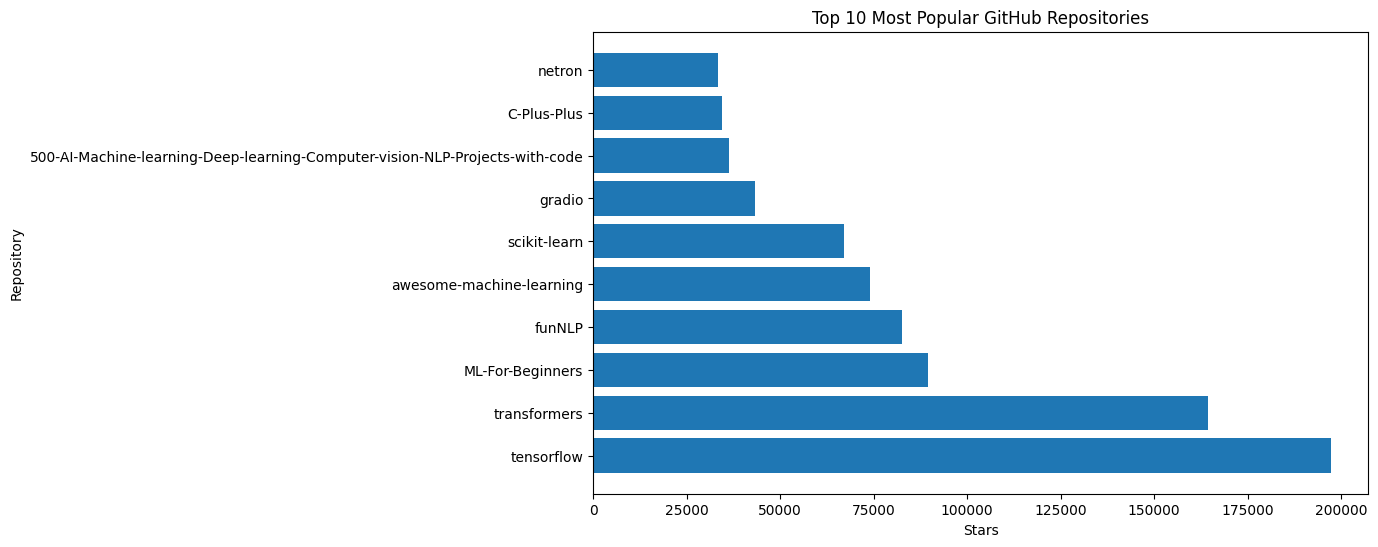

In [232]:
plt.figure(figsize=(10, 6))

plt.barh(top_10["name"], top_10["stars"])

plt.xlabel("Stars")
plt.ylabel("Repository")
plt.title("Top 10 Most Popular GitHub Repositories")

plt.show()

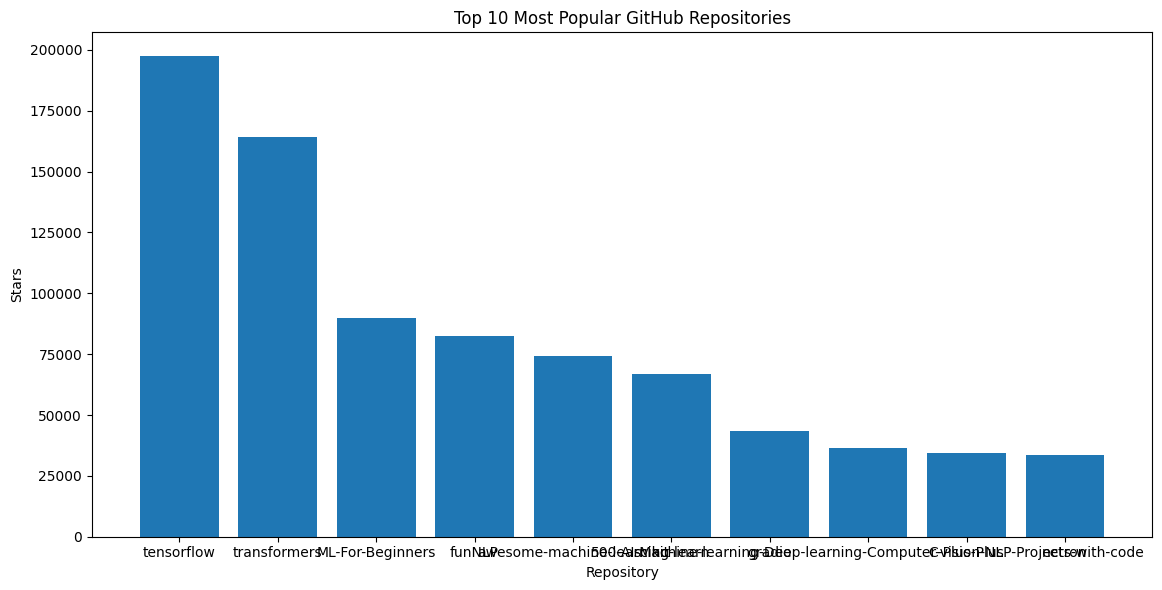

In [233]:
plt.figure(figsize=(12, 6))

plt.bar(top_10["name"], top_10["stars"])

plt.xlabel("Repository")
plt.ylabel("Stars")
plt.title("Top 10 Most Popular GitHub Repositories")

plt.tight_layout()

plt.show()

Chart 2: Repository Creation Trends

In [234]:
query = """
SELECT created_date
FROM Repositories
"""

creation_dates = pd.read_sql(query, connection)

In [235]:
creation_dates["created_date"] = pd.to_datetime(
    creation_dates["created_date"]
)

In [236]:
creation_dates["year"] = creation_dates["created_date"].dt.year

In [237]:
yearly_repositories = (
    creation_dates
    .groupby("year")
    .size()
    .reset_index(name="repository_count")
)

yearly_repositories

,year,repository_count
0,2009,1
1,2010,2
2,2011,2
3,2013,3
4,2014,6
5,2015,7
6,2016,14
7,2017,17
8,2018,18
9,2019,7


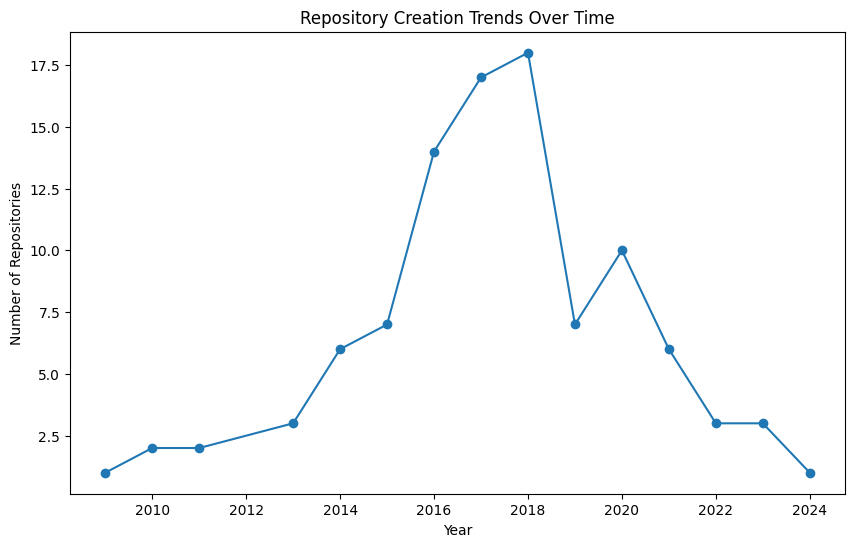

In [238]:
plt.figure(figsize=(10, 6))

plt.plot(
    yearly_repositories["year"],
    yearly_repositories["repository_count"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Number of Repositories")
plt.title("Repository Creation Trends Over Time")

plt.show()

## **Interpretation of Results**

The analysis shows that some Machine Learning repositories are much more popular than others, with a small number of repositories having very high star counts.

The Top 10 analysis shows that repositories such as TensorFlow and Transformers have a large number of stars compared with many other repositories in the dataset.

The programming language analysis helps show which languages are commonly used among the repositories collected from GitHub.

The creation trend chart shows how the number of repositories in the dataset has changed over the years. This helps us understand how Machine Learning repositories have developed over time.

Overall, the analysis shows that Machine Learning is represented by a wide range of repositories with different levels of popularity, programming languages, and creation dates.

##**Ethics Reflection**

1. Why is it important to verify data collected from public APIs?

It is important to verify data collected from public APIs because the data may contain missing, incorrect, or outdated information. Checking the data helps make sure that the results of the analysis are accurate and reliable.

2. Why should data analysts document the source of their data?

Data analysts should document the source of their data so that others can understand where the data came from and how it was collected. In this project, the data was collected from the GitHub API. Documenting the source also makes the analysis more transparent and easier to reproduce.

3. How can missing or inaccurate data affect data analysis and decision-making?

Missing or inaccurate data can lead to incorrect results and misleading conclusions. For example, if some repositories have missing star counts or programming languages, the calculations and comparisons may not accurately represent the dataset. This can affect the decisions made based on the analysis.